# Pycaret 및 rulefit 설치
설치후 런타임 - 세션 재시작 하고 한글폰트 설치 코드부터 시행

In [ ]:
!pip install -U pip setuptools wheel
!pip install -U scikit-learn imbalanced-learn
!pip install -U "git+https://github.com/pycaret/pycaret.git@master"
!pip install -U jinja2
!pip install rulefit
!pip install catboost
!pip install scikit_posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.8 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 16.4 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-_lmgrnm9
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-_lmgrnm9
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
IN

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rulefit: filename=rulefit-0.3.1-py3-none-any.whl size=7864 sha256=9790b31fc64272867485474f43c9d1a7438f81d9284f84e1ad59db53e629f89b
  Stored in directory: /root/.cache/pip/wheels/40/ae/a3/ad2ff0555b4b268ff64c3ed0093a3b5daf92748ff94c3e6968
Successfully built rulefit
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 46.1 MB/s  0:00:02


# 한글 폰트 설치(상관 히트맵 용)

In [ ]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections

    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

Selecting previously unselected package fonts-nanum.
(Reading database ... 121703 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import skew, kurtosis
#from pycaret.classification import *
#from pycaret.classification import get_config
#from rulefit import RuleFit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold



plt.rcParams['font.family'] = 'NanumGothic' # 한글 불러오기
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/novicedata/Paper/refs/heads/main/MZ_turnover/data/gong2024.csv') # 데이터 불러오기
df

,ID,q1,q1_1_m1,q1_1_m2,q2,q3_1,q3_2,q3_3,q4_1,q4_2,...,orgtype,DM1,DM2,DM3,DM4,DM5,DM6,DM7,WT,TWT
0,2.0,4.0,2.0,7.0,3.0,3.0,3.0,3.0,3.0,3.0,...,5.0,2.0,2.0,3.0,3.0,3.0,2.0,3.0,18.736111,0.521818
1,3.0,4.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,...,1.0,1.0,1.0,2.0,3.0,2.0,1.0,4.0,30.000000,0.835356
2,5.0,3.0,NaN,NaN,4.0,3.0,2.0,2.0,3.0,3.0,...,1.0,1.0,1.0,2.0,3.0,2.0,1.0,3.0,11.954545,0.332877
3,6.0,4.0,5.0,6.0,1.0,5.0,3.0,5.0,4.0,4.0,...,3.0,1.0,1.0,3.0,3.0,3.0,2.0,3.0,5.076923,0.141368
4,9.0,5.0,2.0,5.0,4.0,3.0,4.0,4.0,4.0,3.0,...,5.0,2.0,2.0,3.0,3.0,5.0,1.0,3.0,63.805085,1.777029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6070,7703.0,3.0,NaN,NaN,3.0,3.0,3.0,3.0,4.0,4.0,...,4.0,1.0,2.0,2.0,3.0,3.0,1.0,3.0,11.785714,0.328176
6071,7704.0,3.0,NaN,NaN,3.0,4.0,4.0,2.0,2.0,4.0,...,2.0,1.0,1.0,3.0,4.0,4.0,1.0,1.0,12.833333,0.357347
6072,7705.0,3.0,NaN,NaN,2.0,2.0,2.0,3.0,3.0,5.0,...,3.0,1.0,1.0,3.0,3.0,4.0,1.0,2.0,7.062500,0.196657
6073,7706.0,3.0,NaN,NaN,3.0,3.0,3.0,3.0,3.0,3.0,...,1.0,1.0,1.0,2.0,3.0,1.0,2.0,3.0,18.388889,0.512043


## 역문항 및 차원 축소

In [ ]:
def preprocessing_binary(df):
    print(f'raw data: {df.shape} \n')

    print(f'MZ data 확인 \n')
    df = df[df['dq2'] >= 1981].copy() # MZ세대 데이터만 추출

    print(f'MZ data: {df.shape} \n')

    print(f'불필요 데이터 삭제 \n')
    remove_col = ['ID', 'q1_1_m1', 'q1_1_m2', 'q5_1', 'q5_2', 'q5_3', 'q5_1_1', 'q5_2_1', 'q5_3_1',
                 'q6_1', 'q6_2', 'q6_3', 'q6_4', 'q6_1_1', 'q6_2_1', 'q6_3_1', 'q6_4_1', 'a',
                 'q9_m1', 'q9_m2', 'q9_m3',
                 'q17_m1', 'q17_m2', 'q18_m1', 'q18_m2', 'q28_m1', 'q28_m2', 'q28_m3', 'b',
                 'q31_C1', 'q31_C2', 'q38_1', 'q38_2_m1', 'q38_2_m2',
                 'dq1', 'DM3', 'DM4', 'DM5', 'DM6', 'DM7', 'WT', 'TWT']

    df = df.drop(remove_col, axis=1)
    print(f'삭제 후 shape: {df.shape} \n')

    # 역문항 수동 처리
    print(f'역문항 처리 \n')
    columns_to_reverse = ['q8_5', 'q14_4', 'q19_5', 'q33_5', 'q33_6', 'q33_7', 'q33_8']

    def reverse(x):
        if x == 5:
            return 1
        elif x == 4:
            return 2
        elif x == 3:
            return 3
        elif x == 2:
            return 4
        else:
            return 5

    for column in columns_to_reverse:
        df[column] = df[column].apply(reverse)

    new_data = df.copy()

    # 문항 요인화(평균으로)
    print(f'유사 문항 평균화 \n')
    new_data['업무량'] = new_data[['q1']]
    new_data['근무환경'] = new_data[['q2']]
    new_data['자원제공'] = new_data[['q3_1', 'q3_2', 'q3_3']].mean(axis=1)
    new_data['업무자율성'] = new_data[['q4_1', 'q4_2', 'q4_3']].mean(axis=1)
    new_data['채용'] = new_data[['q7_1', 'q7_2', 'q7_3', 'q7_4']].mean(axis=1)
    new_data['승진'] = new_data[['q8_1', 'q8_2', 'q8_3', 'q8_4', 'q8_5']].mean(axis=1)
    new_data['배치전환'] = new_data[['q10_1', 'q10_2', 'q10_3']].mean(axis=1)
    new_data['보수 및 보상'] = new_data[['q11_1', 'q11_2', 'q11_3', 'q11_4']].mean(axis=1)
    new_data['호봉제'] = new_data[['q12']]
    new_data['후생복지'] = new_data[['q13_1', 'q13_2']].mean(axis=1)
    new_data['교육훈련/능력발전'] = new_data[['q14_1', 'q14_2', 'q14_3', 'q14_4']].mean(axis=1)
    new_data['업무 수행 역량'] = new_data[['q15_1', 'q15_2', 'q15_3']].mean(axis=1)
    new_data['전문성 수준'] = new_data[['q16_1', 'q16_2']].mean(axis=1)
    new_data['조직목표'] = new_data[['q19_1', 'q19_2', 'q19_3', 'q19_4', 'q19_5']].mean(axis=1)
    new_data['리더십'] = new_data[['q20_1', 'q20_2', 'q20_3', 'q20_4', 'q20_5', 'q20_6', 'q20_7']].mean(axis=1)
    new_data['과업지향 조직문화'] = new_data[['q21_1', 'q21_2']].mean(axis=1)
    new_data['혁신지향 조직문화'] = new_data[['q21_3', 'q21_7']].mean(axis=1)
    new_data['관계지향 조직문화'] = new_data[['q21_4', 'q21_8']].mean(axis=1)
    new_data['위계질서 조직문화'] = new_data[['q21_5', 'q21_6']].mean(axis=1)
    new_data['조직 냉소주의'] = new_data[['q21_9', 'q21_10']].mean(axis=1)
    new_data['조직 내 정치'] = new_data[['q21_11', 'q21_12']].mean(axis=1)
    new_data['의사결정'] = new_data[['q22_1', 'q22_2', 'q22_3', 'q22_4']].mean(axis=1)
    new_data['변화관리'] = new_data[['q23_1', 'q23_2', 'q23_3']].mean(axis=1)
    new_data['협업/의사소통'] = new_data[['q24_1', 'q24_2', 'q24_3']].mean(axis=1)
    new_data['조직성과'] = new_data[['q25_1', 'q25_2']].mean(axis=1)
    new_data['성과관리'] = new_data[['q26_1', 'q26_2', 'q26_3', 'q26_4', 'q26_5']].mean(axis=1)
    new_data['업무성과'] = new_data[['q27_1', 'q27_2', 'q27_3']].mean(axis=1)
    new_data['부정부패'] = new_data[['q29']]
    new_data['공공봉사동기'] = new_data[['q30_1', 'q30_2', 'q30_3', 'q30_4', 'q30_5', 'q30_6']].mean(axis=1)
    new_data['역할갈등'] = new_data[['q31_1', 'q31_2', 'q31_3']].mean(axis=1)
    new_data['역할모호성'] = new_data[['q31_4', 'q31_5', 'q31_6']].mean(axis=1)
    new_data['업무 과중'] = new_data[['q31_7']]
    new_data['조직시민행동'] = new_data[['q32_1', 'q32_2', 'q32_3', 'q32_4', 'q32_5']].mean(axis=1)
    new_data['혁신행동'] = new_data[['q33_1', 'q33_2', 'q33_3', 'q33_4', 'q33_5', 'q33_6', 'q33_7', 'q33_8']].mean(axis=1)
    new_data['공직가치'] = new_data[['q34_1', 'q34_2', 'q34_3', 'q34_4', 'q34_5', 'q34_6', 'q34_7', 'q34_8']].mean(axis=1)
    new_data['조직몰입'] = new_data[['q35_1', 'q35_2', 'q35_3', 'q35_4']].mean(axis=1)
    new_data['직무만족'] = new_data[['q36_1', 'q36_2', 'q36_3']].mean(axis=1)
    new_data['공직만족도'] = new_data[['q37_1', 'q37_2', 'q37_3', 'q37_4']].mean(axis=1)
    new_data['삶의 질'] = new_data[['q39_1', 'q39_2']].mean(axis=1)
    new_data['성별'] = new_data[['DM2']]
    new_data['출생 연도'] = new_data[['dq2']]
    new_data['혼인상태'] = new_data[['dq3']]
    new_data['전체 자녀의 수'] = new_data[['dq4_1']]
    new_data['만 20세 미만 자녀의 수'] = new_data[['dq4_2']]
    new_data['입직당시 학력'] = new_data[['dq5_1']]
    new_data['현재 학력'] = new_data[['dq5_2']]
    new_data['입직 준비기간'] = new_data[['dq6']]
    new_data['재직기간'] = new_data[['dq7']]
    new_data['입직 시 채용 방식'] = new_data[['dq8']]
    new_data['입직당시 직급'] = new_data[['dq9_1']]
    new_data['현재 직급'] = new_data[['dq9_2']]
    new_data['1개월 평균 급여수준'] = new_data[['dq10']]
    new_data['1주일 평균 근무시간'] = new_data[['dq11']]
    new_data['기관유형'] = new_data[['orgtype']]
    new_data['기관구분'] = new_data[['DM1']]


    # 평균화 후, 요인만 남기고 문항 제거
    print(f'불필요 데이터 삭제 2 \n')

    remove_col2 = [
        'DM2', 'dq2', 'dq3', 'dq4_1', 'dq4_2', 'dq5_1', 'dq5_2',
        'dq6', 'dq7', 'dq8', 'dq9_1', 'dq9_2', 'dq10', 'dq11', 'orgtype', 'DM1',
        'q1', 'q2',
                   "q3_1", "q3_2", "q3_3",
      "q4_1", "q4_2", "q4_3",
      "q7_1", "q7_2", "q7_3", "q7_4",
      "q8_1", "q8_2", "q8_3", "q8_4", "q8_5",
      "q10_1", "q10_2", "q10_3",
      "q11_1", "q11_2", "q11_3", "q11_4", 'q12',
      "q13_1", "q13_2",
      "q14_1", "q14_2", "q14_3", "q14_4",
      "q15_1", "q15_2", "q15_3", 'q16_1', 'q16_2',
      "q19_1", "q19_2", "q19_3", "q19_4", "q19_5",
      "q20_1", "q20_2", "q20_3", "q20_4", "q20_5", "q20_6", "q20_7",
      'q21_1', 'q21_2', 'q21_3', 'q21_5', 'q21_6', 'q21_7', 'q21_4', 'q21_8', 'q21_9', 'q21_10', 'q21_11', 'q21_12',
      "q22_1", "q22_2", "q22_3", "q22_4",
      "q23_1", "q23_2", "q23_3",
      "q24_1", "q24_2", "q24_3",
      "q25_1", "q25_2",
      "q26_1", "q26_2", "q26_3", "q26_4", "q26_5",
      "q27_1", "q27_2", "q27_3", 'q29',
      "q30_1", "q30_2", "q30_3", "q30_4", "q30_5", "q30_6",
      "q31_1", "q31_2", "q31_3", "q31_4", "q31_5", "q31_6", "q31_7",
      "q32_1", "q32_2", "q32_3", "q32_4", "q32_5",
      "q33_1", "q33_2", "q33_3", "q33_4", "q33_5", "q33_6", "q33_7", "q33_8",
      "q34_1", "q34_2", "q34_3", "q34_4", "q34_5", "q34_6", "q34_7", "q34_8",
      "q35_1", "q35_2", "q35_3", "q35_4",
      "q36_1", "q36_2", "q36_3",
      "q37_1", "q37_2", "q37_3", "q37_4",
      "q39_1", "q39_2"]

    new_data = new_data.drop(remove_col2, axis=1)
    print(f'불필요 칼럼 처리2 : {new_data.shape}', '\n')

    # 종속변수인 이직의도 이진화
    print(f'이직의도 이진화 \n')
    condition1 = [
        (df['q38'] <=3),
        (df['q38'] > 3)
    ]
    choice1 = [0, 1]
    new_data.loc[:, '이직의도'] = np.select(condition1, choice1, default = np.nan)
    new_data = new_data.drop(['q38'], axis=1)

    return new_data

In [ ]:
data = preprocessing_binary(df) # 원데이터에서 전처리

raw data: (6075, 187) 

MZ data 확인 

MZ data: (4142, 187) 

불필요 데이터 삭제 

삭제 후 shape: (4142, 145) 

역문항 처리 

유사 문항 평균화 

불필요 데이터 삭제 2 

불필요 칼럼 처리2 : (4142, 56) 

이직의도 이진화 



In [ ]:
# 재직기간별 이직의도 비율 계산
turnover_by_tenure = (
    data.groupby('재직기간')['이직의도']
    .mean()  # 1의 비율 = 이직의도 비율
    .reset_index()
    .rename(columns={'이직의도': '이직의도 비율'})
)

# 보기 좋게 정렬
turnover_by_tenure = turnover_by_tenure.sort_values('재직기간')
print(turnover_by_tenure)

# 1 (5년 이하), 2 (6~10년), 3 (11~15년),
# 4 (16~20년), 5 (21~25년), 6 (26년 이상)

   재직기간   이직의도 비율
0   1.0  0.556647
1   2.0  0.598214
2   3.0  0.489796
3   4.0  0.430000
4   5.0  0.368421


# 기술 통계

## 크론바흐 알파

In [ ]:
# 크론바흐 알파
def cronbach_alpha(df):
    df = df.dropna()
    item_vars = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    n_items = df.shape[1]
    return round(n_items / (n_items - 1) * (1 - item_vars.sum() / total_var), 3)

# 역문항 목록
columns_to_reverse = ['q8_5', 'q14_4', 'q19_5', 'q33_5', 'q33_6', 'q33_7', 'q33_8']

# 역문항 처리 (1~5 리커트)
df_reversed = df.copy()
for col in columns_to_reverse:
    if col in df_reversed.columns:
        df_reversed[col] = df_reversed[col].apply(lambda x: 6 - x if pd.notnull(x) else np.nan)

# 측정하고 싶은 변수 집합 (원문항 기준)
scales = {
    '자원제공': ['q3_1', 'q3_2', 'q3_3'],
    '업무자율성': ['q4_1', 'q4_2', 'q4_3'],
    '채용': ['q7_1', 'q7_2', 'q7_3', 'q7_4'],
    '승진': ['q8_1', 'q8_2', 'q8_3', 'q8_4', 'q8_5'],
    '배치전환': ['q10_1', 'q10_2', 'q10_3'],
    '보수 및 보상': ['q11_1', 'q11_2', 'q11_3', 'q11_4'],
    '후생복지': ['q13_1', 'q13_2'],
    '교육훈련/능력발전': ['q14_1', 'q14_2', 'q14_3', 'q14_4'],
    '업무 수행 역량': ['q15_1', 'q15_2', 'q15_3'],
    '전문성 수준': ['q16_1', 'q16_2'],
    '조직목표': ['q19_1', 'q19_2', 'q19_3', 'q19_4', 'q19_5'],
    '리더십': ['q20_1', 'q20_2', 'q20_3', 'q20_4', 'q20_5', 'q20_6', 'q20_7'],
    '과업지향 조직문화': ['q21_1', 'q21_2'],
    '혁신지향 조직문화': ['q21_3', 'q21_7'],
    '관계지향 조직문화': ['q21_4', 'q21_8'],
    '위계질서 조직문화': ['q21_5', 'q21_6'],
    '조직 냉소주의': ['q21_9', 'q21_10'],
    '조직 내 정치': ['q21_11', 'q21_12'],
    '의사결정': ['q22_1', 'q22_2', 'q22_3', 'q22_4'],
    '변화관리': ['q23_1', 'q23_2', 'q23_3'],
    '협업/의사소통': ['q24_1', 'q24_2', 'q24_3'],
    '조직성과': ['q25_1', 'q25_2'],
    '성과관리': ['q26_1', 'q26_2', 'q26_3', 'q26_4', 'q26_5'],
    '업무성과': ['q27_1', 'q27_2', 'q27_3'],
    '공공봉사동기': ['q30_1', 'q30_2', 'q30_3', 'q30_4', 'q30_5', 'q30_6'],
    '역할갈등': ['q31_1', 'q31_2', 'q31_3'],
    '역할모호성': ['q31_4', 'q31_5', 'q31_6'],
    '조직시민행동': ['q32_1', 'q32_2', 'q32_3', 'q32_4', 'q32_5'],
    '혁신행동': ['q33_1', 'q33_2', 'q33_3', 'q33_4', 'q33_5', 'q33_6', 'q33_7', 'q33_8'],
    '공직가치': ['q34_1', 'q34_2', 'q34_3', 'q34_4', 'q34_5', 'q34_6', 'q34_7', 'q34_8'],
    '조직몰입': ['q35_1', 'q35_2', 'q35_3', 'q35_4'],
    '직무만족': ['q36_1', 'q36_2', 'q36_3'],
    '공직만족도': ['q37_1', 'q37_2', 'q37_3', 'q37_4'],
    '삶의 질': ['q39_1', 'q39_2']
}


# 결과 저장
results = []

for name, items in scales.items():
    valid_items = [col for col in items if col in df_reversed.columns]
    if len(valid_items) < 2:
        results.append({'변수': name, '문항 수': len(valid_items), 'Alpha': '문항 부족'})
    else:
        alpha_val = cronbach_alpha(df_reversed[valid_items])
        results.append({
            '변수': name,
            '문항 수': len(valid_items),
            'Alpha': round(alpha_val, 3) if not np.isnan(alpha_val) else '계산 불가'
        })

# 결과 출력
alpha_df = pd.DataFrame(results)
alpha_df = alpha_df.sort_values(by='변수').reset_index(drop=True)
print(alpha_df)


           변수  문항 수  Alpha
0      공공봉사동기     6  0.902
1        공직가치     8  0.899
2       공직만족도     4  0.845
3   과업지향 조직문화     2  0.832
4   관계지향 조직문화     2  0.633
5   교육훈련/능력발전     4  0.736
6         리더십     7  0.952
7        배치전환     3  0.763
8        변화관리     3  0.877
9     보수 및 보상     4  0.950
10       삶의 질     2  0.818
11       성과관리     5  0.929
12         승진     5  0.775
13   업무 수행 역량     3  0.592
14       업무성과     3  0.890
15      업무자율성     3  0.837
16       역할갈등     3  0.826
17      역할모호성     3  0.895
18  위계질서 조직문화     2  0.774
19       의사결정     4  0.919
20       자원제공     3  0.828
21     전문성 수준     2  0.658
22    조직 내 정치     2  0.754
23    조직 냉소주의     2  0.797
24       조직목표     5  0.813
25       조직몰입     4  0.867
26       조직성과     2  0.893
27     조직시민행동     5  0.810
28       직무만족     3  0.849
29         채용     4  0.830
30  혁신지향 조직문화     2  0.628
31       혁신행동     8  0.852
32    협업/의사소통     3  0.852
33       후생복지     2  0.868


## 최대, 최소, 중앙, 평균, 표준편차, 왜도, 첨도

In [ ]:
# 범주형 변수 리스트
categorical_vars = [
    '성별', '혼인상태',
    '입직당시 학력', '현재 학력',
    '입직 준비기간', '재직기간', '입직 시 채용 방식',
    '입직당시 직급', '현재 직급',
    '1개월 평균 급여수준', '1주일 평균 근무시간',
    '기관유형', '기관구분', '이직의도'
]

# 수치형 변수 추출
numeric_data = data.drop(columns=categorical_vars)

# 최빈값 계산 함수
def get_mode(series):
    return series.mode().iloc[0] if not series.mode().empty else None

# 1. 수치형 변수 기술 통계 요약 (왜도, 첨도 포함)
summary = pd.DataFrame({
    'min': numeric_data.min(),
    'max': numeric_data.max(),
    'mode': numeric_data.apply(get_mode),
    'mean': numeric_data.mean(),
    'std': numeric_data.std(),
    'skewness': numeric_data.apply(skew),
    'kurtosis': numeric_data.apply(lambda x: kurtosis(x, fisher=True) + 3)
}).round(3)

sorted_columns = sorted(summary.index, key=lambda x: x)
summary = summary.reindex(sorted_columns).round(3)

print("수치형 변수 기술 통계")
display(summary)


# 2. 범주형 변수 빈도표 출력
for col in categorical_vars:
    print(f"\n▶ 변수: {col}")
    freq = data[col].value_counts(dropna=False)
    percent = data[col].value_counts(normalize=True, dropna=False) * 100

    freq_table = pd.DataFrame({
        '빈도': freq,
        '비율(%)': percent.round(2)
    })

    print(freq_table)

summary.to_csv('summary_stats.csv', encoding='utf-8-sig')

수치형 변수 기술 통계


,min,max,mode,mean,std,skewness,kurtosis
공공봉사동기,1.0,5.0,3.0,3.011,0.742,-0.218,3.825
공직가치,1.0,5.0,3.0,3.460,0.576,-0.165,4.568
공직만족도,1.0,5.0,3.0,2.698,0.832,-0.008,3.003
과업지향 조직문화,1.0,5.0,3.0,3.469,0.759,-0.409,3.933
관계지향 조직문화,1.0,5.0,3.0,3.170,0.768,-0.279,3.599
교육훈련/능력발전,1.0,5.0,3.0,2.877,0.678,-0.236,3.505
근무환경,1.0,5.0,3.0,2.995,1.023,-0.177,2.470
리더십,1.0,5.0,3.0,3.088,0.844,-0.288,3.336
만 20세 미만 자녀의 수,0.0,4.0,0.0,0.413,0.738,1.600,4.392
배치전환,1.0,5.0,3.0,3.055,0.700,-0.292,4.216



▶ 변수: 성별
       빈도  비율(%)
성별              
2.0  2187   52.8
1.0  1955   47.2

▶ 변수: 혼인상태
        빈도  비율(%)
혼인상태             
2.0   2416  58.33
1.0   1726  41.67

▶ 변수: 입직당시 학력
           빈도  비율(%)
입직당시 학력             
3.0      3407  82.25
1.0       446  10.77
4.0       148   3.57
2.0       127   3.07
5.0        14   0.34

▶ 변수: 현재 학력
         빈도  비율(%)
현재 학력             
3.0    3503  84.57
1.0     257   6.20
4.0     244   5.89
2.0     114   2.75
5.0      24   0.58

▶ 변수: 입직 준비기간
           빈도  비율(%)
입직 준비기간             
2.0      1510  36.46
1.0      1157  27.93
3.0       973  23.49
4.0       351   8.47
5.0       151   3.65

▶ 변수: 재직기간
        빈도  비율(%)
재직기간             
1.0   1730  41.77
2.0   1456  35.15
3.0    637  15.38
4.0    300   7.24
5.0     19   0.46

▶ 변수: 입직 시 채용 방식
              빈도  비율(%)
입직 시 채용 방식             
1.0         3697  89.26
2.0          434  10.48
4.0            8   0.19
3.0            3   0.07

▶ 변수: 입직당시 직급
           빈도  비율(%)
입직당시 직급             
9.0      31

## 상관

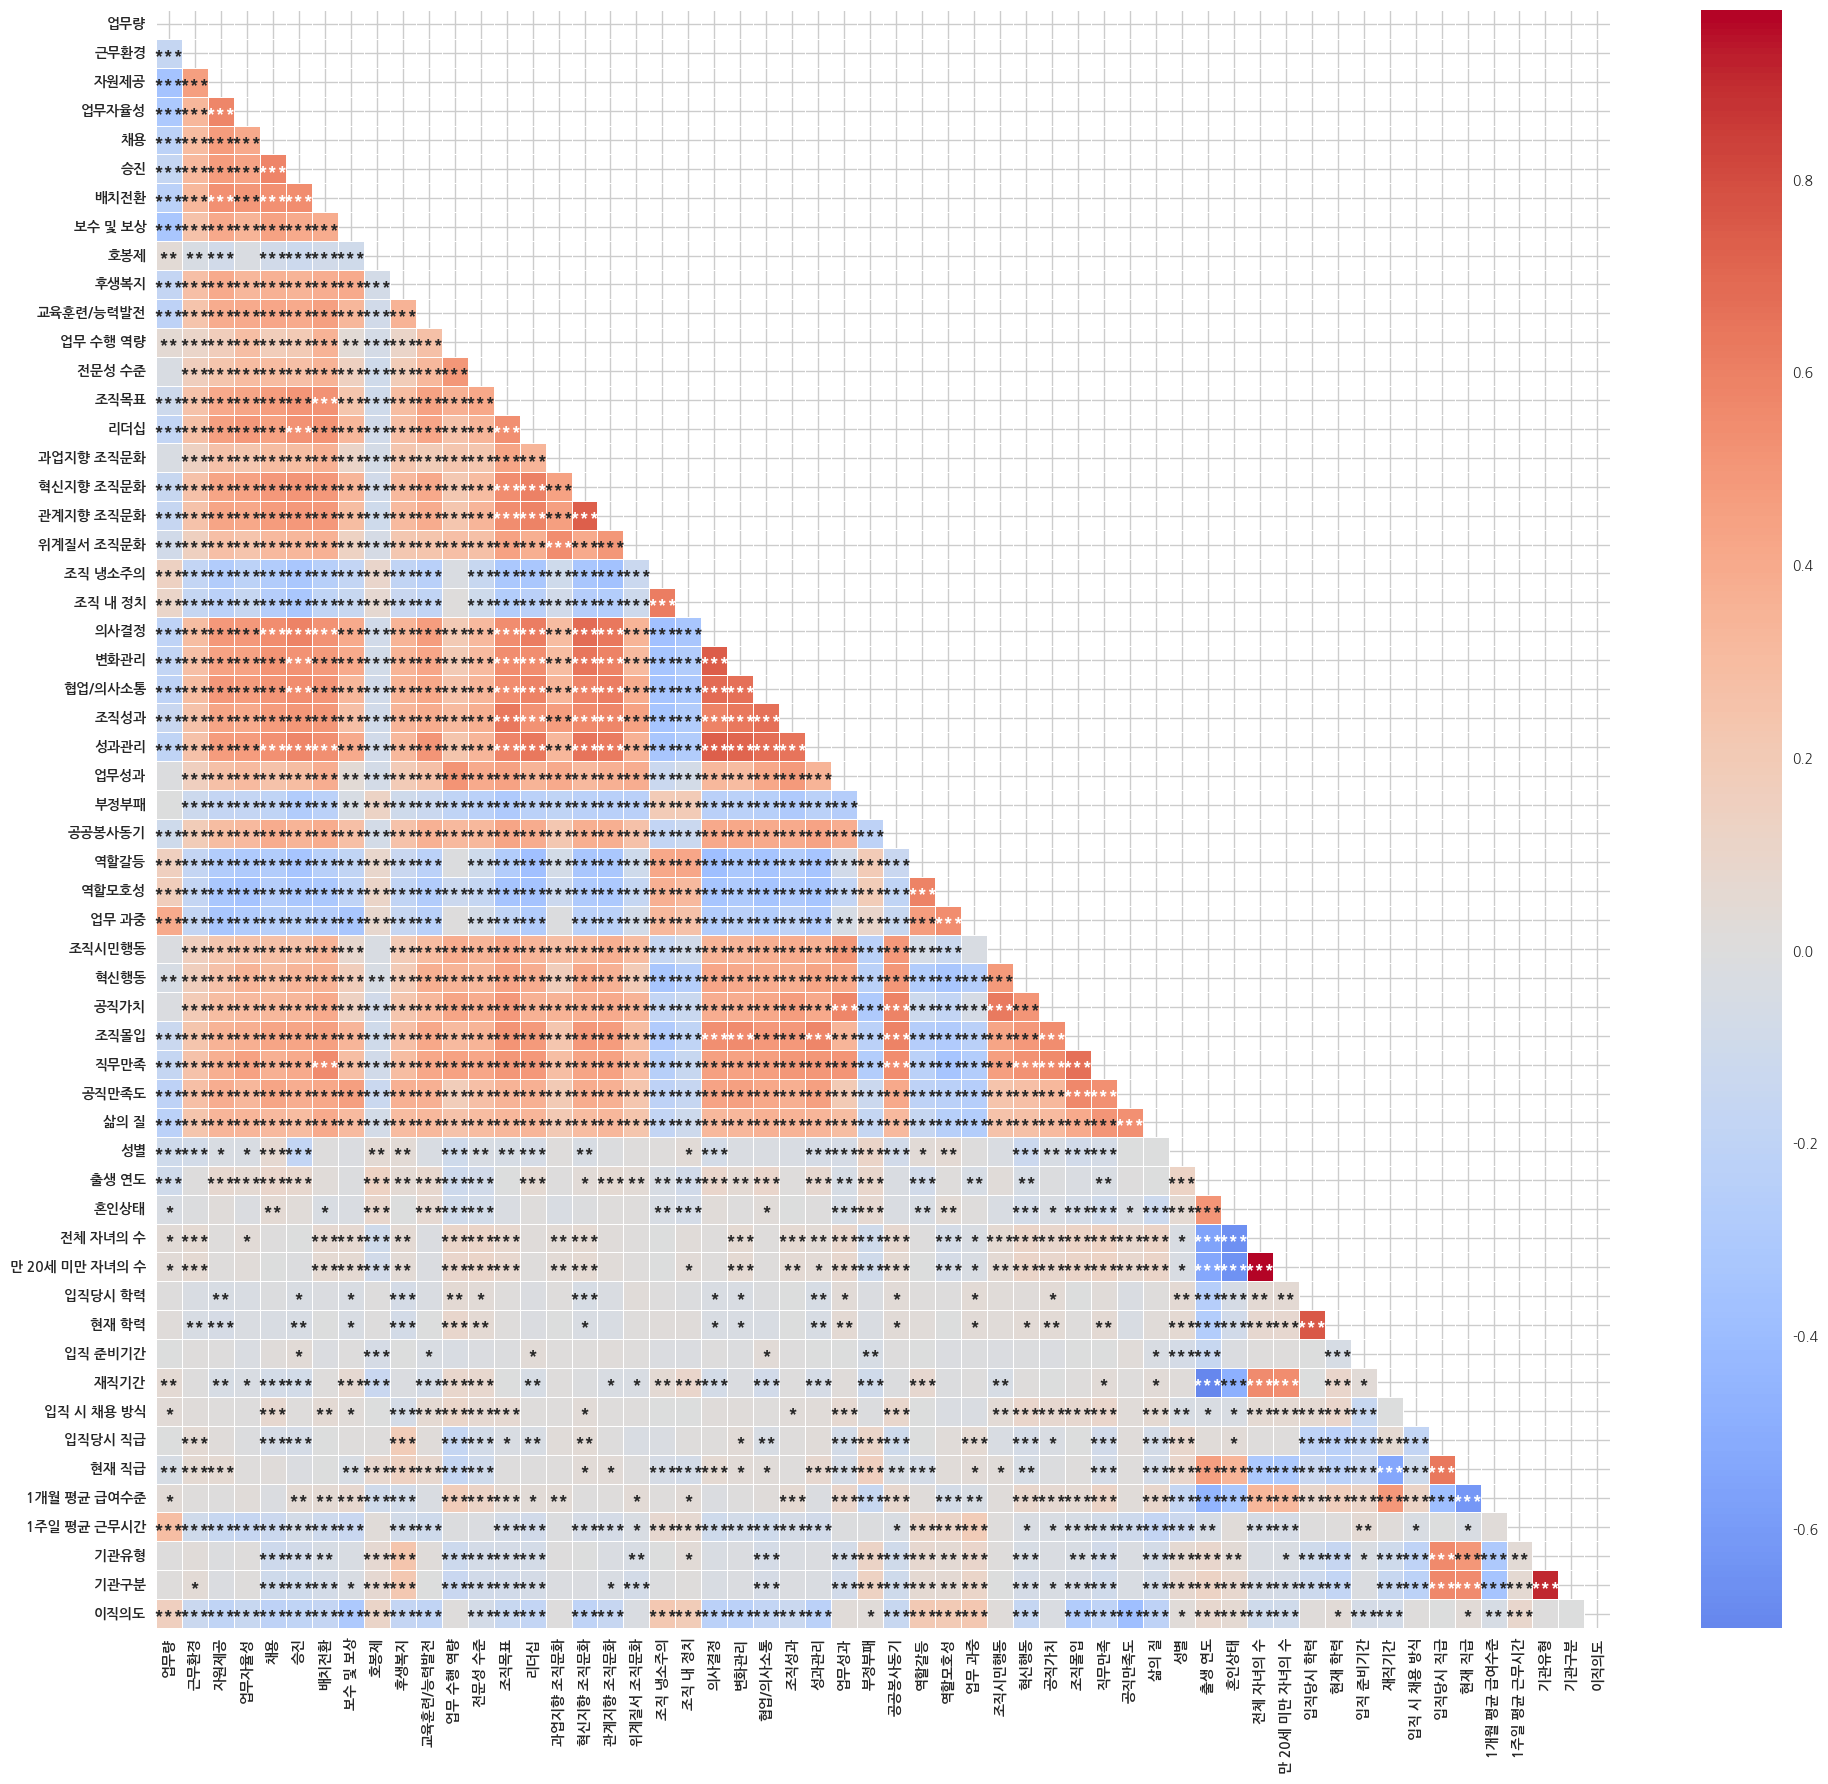

In [ ]:
# 데이터 불러오기(수치형)
df_numeric = data.select_dtypes(include='number')
cols = df_numeric.columns
corr = df_numeric.corr().round(3)

# 상관계수 및 p-value 저장
pval_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
stars_matrix = pd.DataFrame(index=cols, columns=cols, dtype=str)

# p-value 계산 및 별 표기
for col1 in cols:
    for col2 in cols:
        _, pval = pearsonr(df_numeric[col1], df_numeric[col2])
        pval_matrix.loc[col1, col2] = pval
        if pval <= 0.001:
            star = '***'
        elif pval <= 0.01:
            star = '**'
        elif pval <= 0.05:
            star = '*'
        else:
            star = ''
        stars_matrix.loc[col1, col2] = star

mask = np.triu(np.ones_like(corr, dtype=bool))  # 상삼각 마스킹

# 히트맵 시각화 (색상은 상관계수로, 글씨는 별만 표시)
corr = df_numeric.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=stars_matrix, mask=mask, fmt='', cmap='coolwarm', center=0, linewidths=0.5,
           annot_kws = {'fontweight' : "bold"})
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=1200)
plt.show()


# 모델 적합(pycaret)

In [ ]:
# 10-fold × 5 repeats (총 25 분할)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

# 동일 전처리/시드
clf = setup(
    data=data,                    # 전처리된 데이터프레임
    target='이직의도',           # 종속변수 (0/1)
    session_id=42,              # 재현성
    fold_strategy=cv,           # 동일 분할기 공유
    fold=10,                     # 내부 표기(무시되지 않도록 유지)
    verbose=False
)

candidates = [
'lr', 'nb', 'knn', 'catboost',
    'dt', 'rf', 'gbc', 'xgboost',
    'lightgbm'
]

# 각 모델 동일조건 튜닝(AUC 기준)
tuned_models = []
for code in candidates:
    base = create_model(code, cross_validation=True)  # 1차 성능 확인
    tuned = tune_model(
        base, optimize='AUC',
        n_iter=10,
        choose_better=True,     # 개선 시 교체
        fold=cv
    )
    tuned_models.append(tuned)

# 재평가(per-fold 원점수 추출)
all_results = []
for m in tuned_models:
    _ = create_model(m, cross_validation=True, fold=cv)
    res = pull().copy()                 # 분할별 메트릭 테이블
    res['model'] = m.__class__.__name__
    all_results.append(res)

res_df = pd.concat(all_results, ignore_index=True)

# 모델별 평균/SD/SE 계산 (SE = SD/sqrt(50))
metrics = ['Accuracy','AUC','Recall','Prec.','F1']
summary = (res_df
           .groupby('model')[metrics]
           .agg(['mean','std'])
          )
for met in metrics:
    summary[(met, 'SE')] = summary[(met, 'std')] / np.sqrt(50)

# 보기 좋게 열 정리
summary = summary.swaplevel(0,1,axis=1).sort_index(axis=1)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7241,0.7933,0.7562,0.7469,0.7516,0.4415,0.4415
1,0.7069,0.7809,0.7125,0.7451,0.7284,0.4104,0.4109
2,0.7207,0.7748,0.7438,0.7484,0.7461,0.4357,0.4358
3,0.7138,0.8010,0.7500,0.7362,0.7430,0.4201,0.4202
4,0.7138,0.7734,0.7625,0.7305,0.7462,0.4185,0.4190
5,0.7172,0.7540,0.7250,0.7532,0.7389,0.4308,0.4312
6,0.7552,0.8172,0.8062,0.7633,0.7842,0.5018,0.5028
7,0.7000,0.7822,0.7673,0.7093,0.7372,0.3890,0.3906
8,0.7414,0.8076,0.7799,0.7561,0.7678,0.4761,0.4764


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7241,0.7935,0.7188,0.7667,0.7419,0.4463,0.4474
1,0.7103,0.7820,0.6750,0.7714,0.7200,0.4227,0.4268
2,0.6897,0.7755,0.6750,0.7397,0.7059,0.3789,0.3806
3,0.7034,0.8000,0.6875,0.7534,0.7190,0.4065,0.4084
4,0.7172,0.7729,0.7125,0.7600,0.7355,0.4325,0.4335
5,0.6931,0.7537,0.6562,0.7554,0.7023,0.3888,0.3929
6,0.7517,0.8172,0.7312,0.8014,0.7647,0.5031,0.5055
7,0.7069,0.7836,0.7170,0.7403,0.7284,0.4103,0.4105
8,0.7483,0.8083,0.7296,0.7945,0.7607,0.4962,0.4982


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 50 folds for each of 10 candidates, totalling 500 fits


...

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5517,0.8358,1.0000,0.5517,0.7111,0.0000,0.0000
1,0.5517,0.8102,1.0000,0.5517,0.7111,0.0000,0.0000
2,0.5517,0.7833,1.0000,0.5517,0.7111,0.0000,0.0000
3,0.5517,0.8060,1.0000,0.5517,0.7111,0.0000,0.0000
4,0.5517,0.8076,1.0000,0.5517,0.7111,0.0000,0.0000
5,0.5517,0.7725,1.0000,0.5517,0.7111,0.0000,0.0000
6,0.5517,0.7975,1.0000,0.5517,0.7111,0.0000,0.0000
7,0.5483,0.8086,1.0000,0.5483,0.7082,0.0000,0.0000
8,0.5483,0.8085,1.0000,0.5483,0.7082,0.0000,0.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7552,0.8351,0.8000,0.7665,0.7829,0.5025,0.5031
1,0.7207,0.8118,0.7438,0.7484,0.7461,0.4357,0.4358
2,0.7103,0.7807,0.7250,0.7436,0.7342,0.4161,0.4163
3,0.7207,0.8132,0.7562,0.7423,0.7492,0.4341,0.4342
4,0.7379,0.8119,0.7812,0.7530,0.7669,0.4679,0.4683
5,0.7138,0.7818,0.7562,0.7333,0.7446,0.4193,0.4196
6,0.7517,0.8191,0.8312,0.7472,0.7870,0.4915,0.4955
7,0.7483,0.8158,0.8050,0.7529,0.7781,0.4880,0.4895
8,0.7379,0.8191,0.7862,0.7485,0.7669,0.4681,0.4688


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
summary['mean']

,AUC,Accuracy,F1,Prec.,Recall
model,,,,,
CatBoostClassifier,0.794012,0.718915,0.743348,0.742392,0.745425
DecisionTreeClassifier,0.739673,0.685648,0.703244,0.729767,0.681000
GaussianNB,0.723023,0.663946,0.657987,0.749275,0.587652
GradientBoostingClassifier,0.791327,0.714731,0.741548,0.734963,0.749387
KNeighborsClassifier,0.741031,0.626017,0.558392,0.808360,0.427681
LGBMClassifier,0.790977,0.717504,0.744119,0.737106,0.752377
LogisticRegression,0.770815,0.701910,0.714848,0.753629,0.680948
RandomForestClassifier,0.791915,0.720346,0.747138,0.738821,0.757087
XGBClassifier,0.785660,0.540512,0.696846,0.540415,0.980769


In [ ]:
summary['std']

,AUC,Accuracy,F1,Prec.,Recall
model,,,,,
CatBoostClassifier,0.111629,0.101207,0.104542,0.104217,0.106861
DecisionTreeClassifier,0.104310,0.096774,0.099555,0.103093,0.101421
GaussianNB,0.103198,0.094436,0.094635,0.106587,0.087697
GradientBoostingClassifier,0.111053,0.100346,0.103995,0.103151,0.106507
KNeighborsClassifier,0.104689,0.089080,0.084798,0.114576,0.070437
LGBMClassifier,0.111122,0.101026,0.104573,0.103610,0.107377
LogisticRegression,0.108521,0.099182,0.100828,0.106788,0.097287
RandomForestClassifier,0.111250,0.101447,0.105020,0.103974,0.108455
XGBClassifier,0.110534,0.076214,0.098367,0.076226,0.138675


In [ ]:
summary['SE']

,AUC,Accuracy,F1,Prec.,Recall
model,,,,,
CatBoostClassifier,0.015787,0.014313,0.014784,0.014739,0.015112
DecisionTreeClassifier,0.014752,0.013686,0.014079,0.014580,0.014343
GaussianNB,0.014594,0.013355,0.013383,0.015074,0.012402
GradientBoostingClassifier,0.015705,0.014191,0.014707,0.014588,0.015062
KNeighborsClassifier,0.014805,0.012598,0.011992,0.016204,0.009961
LGBMClassifier,0.015715,0.014287,0.014789,0.014653,0.015185
LogisticRegression,0.015347,0.014026,0.014259,0.015102,0.013758
RandomForestClassifier,0.015733,0.014347,0.014852,0.014704,0.015338
XGBClassifier,0.015632,0.010778,0.013911,0.010780,0.019612


In [ ]:
# AUC 기준 최고 성능 보인 random forest 모델 튜닝 (10 iter)
from sklearn.model_selection import RepeatedStratifiedKFold
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
clf = setup(
    data=data,
    target='이직의도',
    session_id=42,
    fold_strategy=cv,
    fold=10,
    verbose=False
)
rf_model = create_model('rf')
tuned_rf = tune_model(
    rf_model,
    optimize = 'AUC',
    choose_better = True,
    n_iter = 10
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7414,0.8214,0.7875,0.7545,0.7706,0.4745,0.4751
1,0.7345,0.8221,0.7625,0.7578,0.7601,0.4628,0.4628
2,0.7069,0.7775,0.7312,0.7358,0.7335,0.4079,0.4079
3,0.7310,0.7972,0.7625,0.7531,0.7578,0.4555,0.4555
4,0.7207,0.8025,0.7625,0.7394,0.7508,0.4333,0.4336
5,0.7138,0.7701,0.7438,0.7391,0.7414,0.4210,0.4210
6,0.7069,0.8099,0.8188,0.7005,0.7550,0.3957,0.4032
7,0.7448,0.8034,0.8050,0.7485,0.7758,0.4807,0.4824
8,0.7414,0.8209,0.7799,0.7561,0.7678,0.4761,0.4764


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7552,0.8221,0.8188,0.7572,0.7868,0.5004,0.5025
1,0.7379,0.8171,0.7500,0.7692,0.7595,0.4717,0.4719
2,0.7414,0.7867,0.7500,0.7742,0.7619,0.4790,0.4793
3,0.7379,0.8122,0.7750,0.7561,0.7654,0.4687,0.4688
4,0.7310,0.8115,0.7688,0.7500,0.7593,0.4547,0.4549
5,0.7207,0.7823,0.7438,0.7484,0.7461,0.4357,0.4358
6,0.7379,0.8232,0.8188,0.7360,0.7751,0.4632,0.4670
7,0.7448,0.8098,0.7987,0.7515,0.7744,0.4814,0.4826
8,0.7345,0.8296,0.7799,0.7470,0.7631,0.4614,0.4620


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 50 folds for each of 10 candidates, totalling 500 fits


# RuleFit 규칙 추출

In [ ]:
tuned_rf

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight={},
                       criterion='entropy', max_depth=9, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0, min_samples_leaf=6,
                       min_samples_split=10, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=230, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [ ]:
# 앞서 random forest 적합할 때 사용한 train, test set 추출
## random forest 적합 시 사용한 데이터만을 rulefit으로 규칙을 추출해야 하기 때문.

X_train = get_config('X_train')
y_train = get_config('y_train')
X_test = get_config('X_test')
y_test = get_config('y_test')

In [ ]:
rf = RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight={},
                       criterion='entropy', max_depth=9, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0, min_samples_leaf=6,
                       min_samples_split=10, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=230, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False) # 앞서 적합한 random forest의 파라미터

rulefit = RuleFit(tree_generator = rf, rfmode='classification', random_state = 19990423) # rulefit setup

In [ ]:
# rulefit 알고리즘에 따라 rule 추출 및 규칙 성능 지표 계산
rulefit.fit(X_train.values, y_train.values, feature_names=X_train.columns)

RuleFit(Cs=None, cv=3, exp_rand_tree_size=True, lin_standardise=True,
        lin_trim_quantile=0.025, max_rules=2000, memory_par=0.01,
        model_type='rl', random_state=19990423, rfmode='classification',
        sample_fract='default',
        tree_generator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight={},
                                              criterion='entropy', max_depth=9,
                                              max_features='sqrt',
                                              max_leaf_nodes=2,
                                              max_samples=None,
                                              min_impurity_decrease=0,
                                              min_samples_leaf=6,
                                              min_samples_split=10,
                                              min_weight_fraction_leaf=0.0,
                                              monotonic_cst=None,
                                              n_estimators=580, n_jobs=-1,
                                              oob_score=False,
                                              random_state=19991002, verbose=0,
                                              warm_start=False),
        tree_size=4)

In [ ]:
rules = rulefit.get_rules()
rules

,rule,type,coef,support,importance
0,업무량,linear,0.0,1.000000,0.0
1,근무환경,linear,0.0,1.000000,0.0
2,자원제공,linear,0.0,1.000000,0.0
3,업무자율성,linear,0.0,1.000000,0.0
4,채용,linear,0.0,1.000000,0.0
...,...,...,...,...,...
1308,조직몰입 <= 2.875 & 조직몰입 > 2.125 & 업무 수행 역량 > 1.16...,rule,0.0,0.267760,0.0
1309,공직만족도 > 2.375 & 교육훈련/능력발전 <= 2.875,rule,0.0,0.222102,0.0
1310,조직 냉소주의 <= 3.25 & 후생복지 <= 2.75 & 혁신행동 > 2.8125...,rule,0.0,0.098298,0.0
1311,역할모호성 <= 3.166666626930237 & 혁신행동 > 2.6875,rule,0.0,0.595791,0.0


### importance

절댓값 계수와 support의 변동성을 곱한 값

규칙이 널리 적용되면서도 충분한 분류력을 갖고 있을 때 중요도가 높아짐.

coef만 크거나 support만 크거나 해서 생기는 편향 방지 지표

coef와 support를 모두 사용하는 지표로 균형잡힌 중요도 지표

In [ ]:
# 규칙(rule)만 필터링하여 중요도 기준 정렬
rules_rules = rules[rules['type'] == 'rule'].copy()

# 중요도 기준 내림차순 정렬 및 importance 0 제거
rules_importance = (
    rules_rules
    .sort_values('importance', ascending=False)
    .query('importance != 0')
    .round(3)
    .reset_index(drop=True)
)

# CSV 저장
rules_importance.to_csv('rules_rules_only.csv', encoding='utf-8-sig', index=False)

# 결과 확인
rules_importance


,rule,type,coef,support,importance
0,공직만족도 <= 2.625 & 전체 자녀의 수 <= 0.5,rule,0.446,0.323,0.209
1,공직만족도 > 2.625 & 직무만족 > 2.833333373069763 & 호봉제...,rule,-0.384,0.376,0.186
2,조직몰입 <= 2.875 & 보수 및 보상 <= 2.125 & 업무 수행 역량 > ...,rule,0.288,0.278,0.129
3,조직 냉소주의 <= 3.25 & 업무 과중 <= 3.5,rule,-0.233,0.559,0.116
4,역할모호성 <= 3.166666626930237 & 공직만족도 > 2.875,rule,-0.235,0.343,0.112
5,공직만족도 <= 2.375 & 협업/의사소통 > 2.833333373069763,rule,0.214,0.179,0.082
6,역할모호성 <= 3.166666626930237 & 조직몰입 > 2.625 & 변화...,rule,-0.166,0.380,0.081
7,보수 및 보상 > 2.625 & 역할갈등 <= 3.833333373069763,rule,-0.166,0.326,0.078
8,보수 및 보상 > 2.625 & 공직만족도 > 2.875 & 삶의 질 > 2.75,rule,-0.189,0.213,0.078
9,승진 > 2.5 & 교육훈련/능력발전 > 2.875 & 조직 내 정치 <= 3.25,rule,-0.137,0.380,0.066


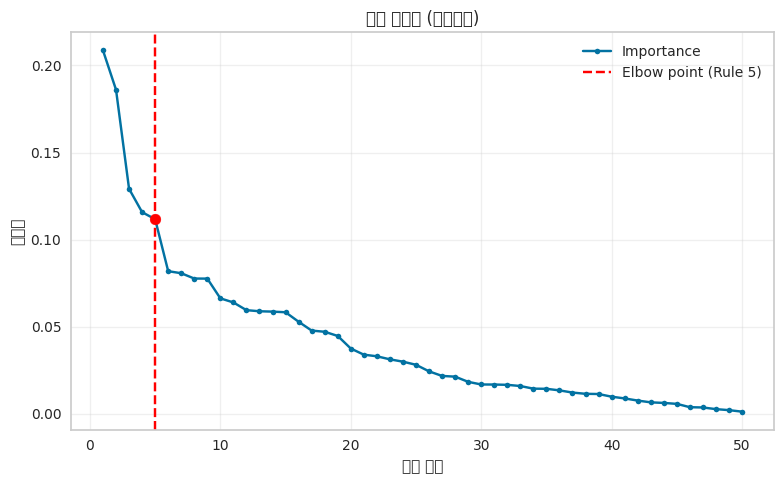

꺾임점 위치: 5번째 규칙, 중요도 값 ≈ 0.112


In [ ]:
rules_imp = rules[(rules['type'] == 'rule') & (rules['importance'] > 0)].sort_values('importance', ascending=False).reset_index(drop=True)
imp_values = rules_imp['importance'].values

# --- elbow index 계산 ---
elbow_idx = 4
elbow_value = imp_values[elbow_idx]

# --- 그래프 시각화 ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(imp_values)+1), imp_values, marker='o', markersize=4, label='Importance')
plt.axvline(elbow_idx+1, color='red', linestyle='--', label=f'Elbow point (Rule {elbow_idx+1})')
plt.scatter(elbow_idx+1, elbow_value, color='red', s=60, zorder=5)
plt.title('규칙 중요도 (내림차순)')
plt.xlabel('규칙 순위')
plt.ylabel('중요도')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"꺾임점 위치: {elbow_idx+1}번째 규칙, 중요도 값 ≈ {elbow_value:.3f}")


In [ ]:
num = 0

# importance 기준 top 5의 규칙, 중요도, 회귀계수, support 추출
for i, j in rules_importance.iterrows():
    if num == 5:
        continue
    else:
        print(f"rule: {j['rule']}")
        print(f"importance: {j['importance']}")
        print(f"coef: {j['coef']}")
        print(f"support: {j['support']}", '\n')

        num += 1

rule: 공직만족도 <= 2.625 & 전체 자녀의 수 <= 0.5
importance: 0.209
coef: 0.446
support: 0.323 

rule: 공직만족도 > 2.625 & 직무만족 > 2.833333373069763 & 호봉제 <= 4.5
importance: 0.186
coef: -0.384
support: 0.376 

rule: 조직몰입 <= 2.875 & 보수 및 보상 <= 2.125 & 업무 수행 역량 > 1.3333333134651184
importance: 0.129
coef: 0.288
support: 0.278 

rule: 조직 냉소주의 <= 3.25 & 업무 과중 <= 3.5
importance: 0.116
coef: -0.233
support: 0.559 

rule: 역할모호성 <= 3.166666626930237 & 공직만족도 > 2.875
importance: 0.112
coef: -0.235
support: 0.343 

